In [62]:
import warnings;
warnings.simplefilter('ignore')


In [63]:
!pip install pystan
!pip install prophet 

Defaulting to user installation because normal site-packages is not writeable
  Using cached pystan-3.10.1-py3-none-any.whl.metadata (3.6 kB)
  Using cached clikit-0.6.2-py2.py3-none-any.whl.metadata (1.6 kB)
INFO: pip is looking at multiple versions of pystan to determine which version is compatible with other requirements. This could take a while.
  Using cached pystan-3.10.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.9.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.9.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.8.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached pystan-3.7.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.6.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.5.0-py3-none-any.whl.metadata (3.7 kB)
INFO: pip is still looking at multiple versions of pystan to determine which version is compatible with other requirements. This could take a while.
  Using cached pystan-3.4.0-py3-none-any.whl.metadata (3.

ERROR: Could not install packages due to an OSError: [Errno 28] No space left on device



Defaulting to user installation because normal site-packages is not writeable


In [84]:
import pandas as pd
from prophet import Prophet

In [65]:
df=pd.read_csv('C:/Users/dwiti/Downloads/dataset.csv')


In [66]:
df.head()

,Time Date,Product,Store,Value
0,1012018,2667437,QLD_CW_ST0203,2926.000
1,2012018,2667437,QLD_CW_ST0203,2687.531
2,3012018,2667437,QLD_CW_ST0203,2793.000
3,4012018,2667437,QLD_CW_ST0203,2394.000
4,5012018,2667437,QLD_CW_ST0203,2660.000


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Time Date  1080 non-null   int64  
 1   Product    1080 non-null   int64  
 2   Store      1080 non-null   object 
 3   Value      1080 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 33.9+ KB


1: Date is not in date format. Clean the date column

In [68]:
df['year']=df['Time Date'].apply(lambda x: str(x)[-4 :])
df['month']=df['Time Date'].apply (lambda x: str(x)[-6 :-4])
df['day']=df['Time Date'].apply(lambda x: str(x)[:-6])
df['ds']=pd.to_datetime(df['year']+'-'+df['month']+'-'+df['day'])

Selecting only one product for forcast now


In [72]:
df['Product'].unique()

array([2667437], dtype=int64)

In [73]:
df['Store'].unique()

array(['QLD_CW_ST0203'], dtype=object)

In [77]:
df = df.loc[(df['Product']==2667437) & (df['Store']=='QLD_CW_ST0203')]
df.drop(['Time Date','Product','Store','year','month','day'],axis=1,inplace=True)
df.columns=['y','ds']


In [78]:
df.head()

,y,ds
0,2926.000,2018-01-01
1,2687.531,2018-01-02
2,2793.000,2018-01-03
3,2394.000,2018-01-04
4,2660.000,2018-01-05


Train Model

In [85]:
m = Prophet(interval_width=0.95, daily_seasonality=True)
model = m.fit(df)

16:53:15 - cmdstanpy - INFO - Chain [1] start processing
16:53:16 - cmdstanpy - INFO - Chain [1] done processing


In [86]:
prediction=m.make_future_dataframe(periods=100,freq='D')
forcast=m.predict(prediction)
forcast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-01-01,3042.707031,906.137871,3927.485150,3042.707031,3042.707031,-636.756103,-636.756103,-636.756103,472.567854,...,16.615615,16.615615,16.615615,-1125.939571,-1125.939571,-1125.939571,0.0,0.0,0.0,2405.950928
1,2018-01-02,3043.438906,815.746648,4038.370669,3043.438906,3043.438906,-646.926343,-646.926343,-646.926343,472.567854,...,-11.291457,-11.291457,-11.291457,-1108.202740,-1108.202740,-1108.202740,0.0,0.0,0.0,2396.512563
2,2018-01-03,3044.170781,811.829711,4029.804806,3044.170781,3044.170781,-621.142084,-621.142084,-621.142084,472.567854,...,-4.423814,-4.423814,-4.423814,-1089.286123,-1089.286123,-1089.286123,0.0,0.0,0.0,2423.028697
3,2018-01-04,3044.902656,792.128849,3932.335453,3044.902656,3044.902656,-574.199279,-574.199279,-574.199279,472.567854,...,22.497906,22.497906,22.497906,-1069.265039,-1069.265039,-1069.265039,0.0,0.0,0.0,2470.703376
4,2018-01-05,3045.634530,802.531372,4085.507178,3045.634530,3045.634530,-610.265676,-610.265676,-610.265676,472.567854,...,-34.566045,-34.566045,-34.566045,-1048.267484,-1048.267484,-1048.267484,0.0,0.0,0.0,2435.368855


In [87]:
forcast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1175,2021-03-22,4237.902086,2037.274055,5306.491548,4234.587199,4241.152758,-509.967235,-509.967235,-509.967235,472.567854,...,16.615615,16.615615,16.615615,-999.150704,-999.150704,-999.150704,0.0,0.0,0.0,3727.934851
1176,2021-03-23,4238.988463,1936.634498,5191.156394,4235.576205,4242.307807,-527.436388,-527.436388,-527.436388,472.567854,...,-11.291457,-11.291457,-11.291457,-988.712785,-988.712785,-988.712785,0.0,0.0,0.0,3711.552075
1177,2021-03-24,4240.074840,2080.621984,5332.807636,4236.565211,4243.481076,-512.908057,-512.908057,-512.908057,472.567854,...,-4.423814,-4.423814,-4.423814,-981.052097,-981.052097,-981.052097,0.0,0.0,0.0,3727.166783
1178,2021-03-25,4241.161217,2227.843120,5319.975779,4237.574602,4244.628357,-481.685763,-481.685763,-481.685763,472.567854,...,22.497906,22.497906,22.497906,-976.751523,-976.751523,-976.751523,0.0,0.0,0.0,3759.475454
1179,2021-03-26,4242.247594,1980.667552,5353.370604,4238.614555,4245.746690,-538.307218,-538.307218,-538.307218,472.567854,...,-34.566045,-34.566045,-34.566045,-976.309027,-976.309027,-976.309027,0.0,0.0,0.0,3703.940376


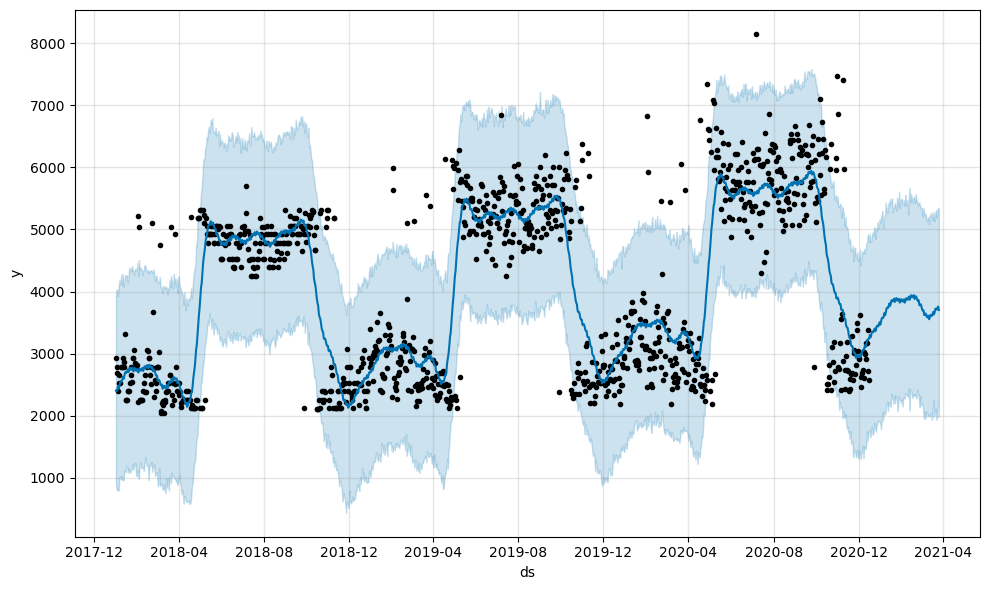

In [88]:
plot=m.plot(forcast)

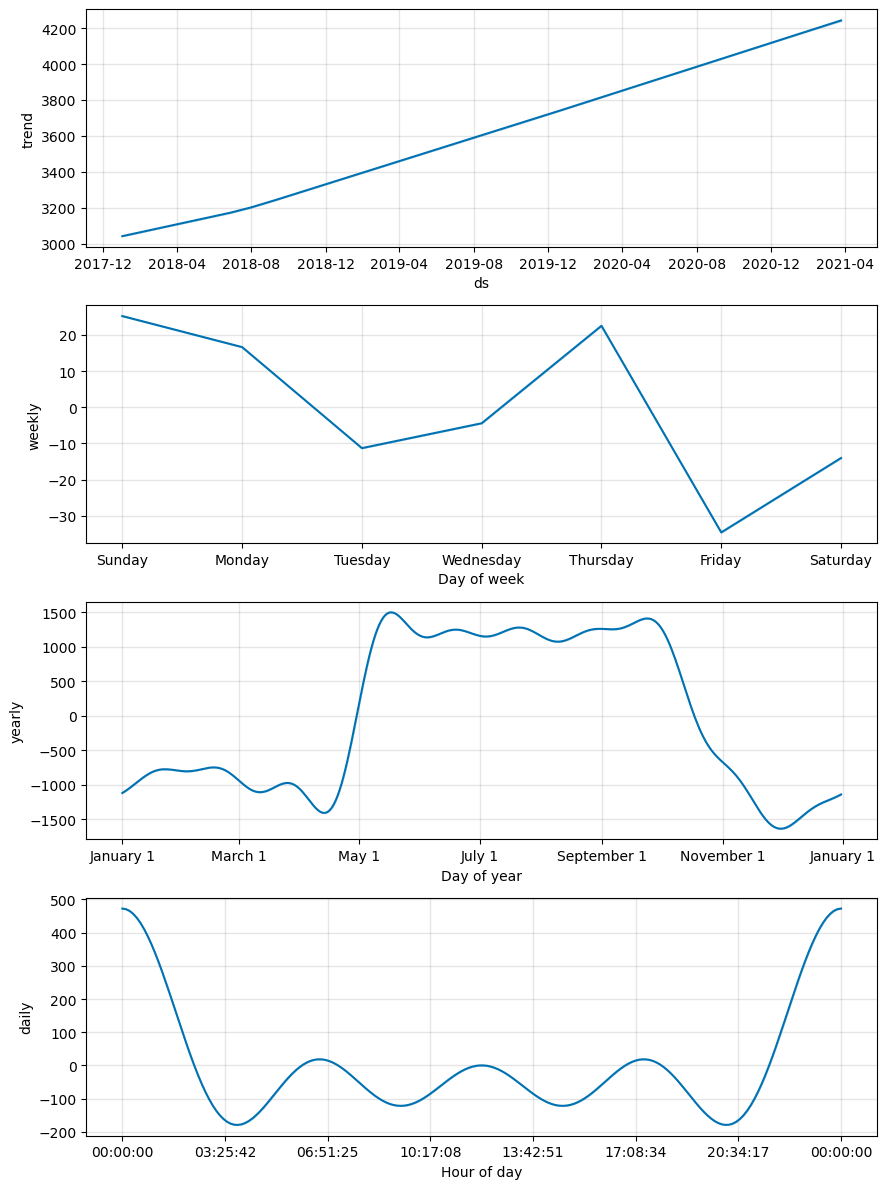

In [89]:
plt2=m.plot_components(forcast)